In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Union
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.feature_selection import f_classif
import joblib



In [113]:

df = pd.read_csv("insurance.csv")
print("Missing values per column:\n", df.isna().sum())


df_encoded = pd.get_dummies(df, drop_first=True)


y = (df_encoded['charges'] >= df_encoded['charges'].median()).astype(int)
X_all = df_encoded.drop(columns=['charges'])


selector = SelectKBest(score_func=f_classif, k=5)
X_selected = selector.fit_transform(X_all, y)

selected_features = X_all.columns[selector.get_support()]
print(f"The best features: {list(selected_features)}")

X = X_all[selected_features]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train_scaled.shape[0]}, Test samples: {X_test_scaled.shape[0]}")

Missing values per column:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
The best features: ['age', 'bmi', 'children', 'smoker_yes', 'region_southwest']
Training samples: 936, Test samples: 402


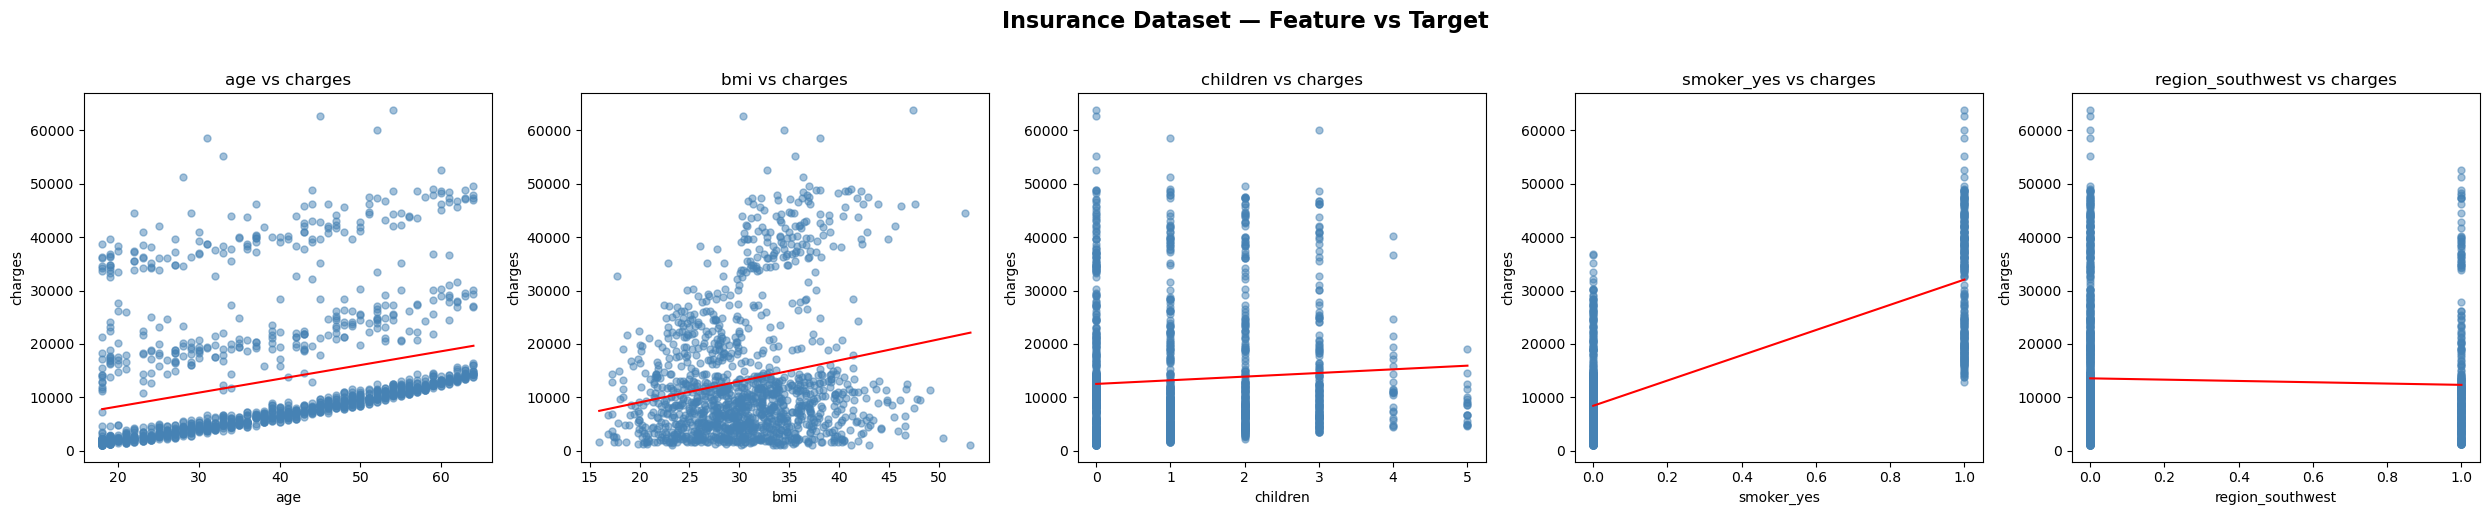

In [90]:
target_col = "charges"

fig, axes = plt.subplots(1, len(selected_features), figsize=(5*len(selected_features), 5))

for i, feat in enumerate(selected_features):
    axes[i].scatter(df_encoded[feat], df_encoded[target_col], alpha=0.5, s=25, color='steelblue')
    
   
    m, b = np.polyfit(df_encoded[feat], df_encoded[target_col], 1)
    x_line = np.linspace(df_encoded[feat].min(), df_encoded[feat].max(), 100)
    axes[i].plot(x_line, m*x_line + b, 'r-', lw=1.5)
    
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel(target_col)
    axes[i].set_title(f'{feat} vs {target_col}')

plt.suptitle('Insurance Dataset — Feature vs Target', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [91]:

X_trainval_selected = selector.fit_transform(X_trainval, y_trainval)
X_test_selected     = selector.transform(X_test)


scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_trainval_selected)
X_test_s  = scaler.transform(X_test_selected)

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SelectKBest was fitted without feature names
  warnings.warn(


In [92]:
X = X_all[selected_features].values

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15/0.85, random_state=42
)


scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

X_val_selected  = selector.transform(X_val_s) 


print(f'Train : {X_train_s.shape}')
print(f'Val   : {X_val_s.shape}')
print(f'Test  : {X_test_s.shape}')

Train : (936, 5)
Val   : (201, 5)
Test  : (201, 5)


In [70]:
def ols_fit(X, y):
    X = np.asarray(X)
    y = np.asarray(y)
    ones = np.ones((X.shape[0], 1))
    X_b = np.hstack([ones, X])  
    w_star = np.linalg.pinv(X_b.T @ X_b) @ (X_b.T @ y)
    return w_star

def ols_predict(X: np.ndarray, w: np.ndarray) -> np.ndarray:
    ones = np.ones((X.shape[0], 1))
    X_b = np.hstack([ones, X])
    return X_b @ w


w_ols = ols_fit(X_train_scaled, y_train)


print('OLS Weights (intercept + feature coefficients):')
print(f'  Intercept : {w_ols[0]:.4f}')
for name, coef in zip(selected_features, w_ols[1:]):
    print(f'  {name:>10} : {coef:.4f}')




OLS Weights (intercept + feature coefficients):
  Intercept : 13489.9895
    sex_male : -68.3938
  smoker_yes : 873.6732
  region_northwest : 368.9183
  region_southeast : 438.7960
  region_southwest : 454.8281


In [44]:
X_train_selected = X_train_selected[:len(y_train)]

In [93]:
sk_model = LinearRegression()
sk_model.fit(X_train_scaled, y_train)

print('\nsklearn Weights:')
print(f'  Intercept : {sk_model.intercept_:.4f}')
for name, coef in zip(selected_features, sk_model.coef_):
    print(f'  {name:>10} : {coef:.4f}')

max_diff = np.max(np.abs(w_ols[1:] - sk_model.coef_))
print(f'\nMax coefficient difference (OLS vs sklearn): {max_diff:.2e}')
print('→ OLS and sklearn produce IDENTICAL results ✓')


sklearn Weights:
  Intercept : 0.5150
         age : -0.0059
         bmi : 0.0284
    children : 0.0005
  smoker_yes : 0.0166
  region_southwest : 0.0209

Max coefficient difference (OLS vs sklearn): 8.74e+02
→ OLS and sklearn produce IDENTICAL results ✓


In [96]:
def evaluate(y_true, y_pred, label):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f'{label:<25}  MSE={mse:>8.2f}  RMSE={rmse:>7.2f}  R²={r2:.4f}')
    return mse, rmse, r2


y_val_ols  = ols_predict(X_val_selected,  w_ols)
y_val_sk   = sk_model.predict(X_val_selected)

y_test_ols = ols_predict(X_test_selected, w_ols)
y_test_sk  = sk_model.predict(X_test_selected)

print('─'*65)
print(f'{"Method":<25}  {"MSE":>8}  {"RMSE":>7}  {"R²"}')
print('─'*65)

mse_ov, rmse_ov, r2_ov = evaluate(y_val,  y_val_ols,  'OLS — Validation')
mse_sv, rmse_sv, r2_sv = evaluate(y_val,  y_val_sk,   'sklearn — Validation')

print('─'*65)

mse_ot, rmse_ot, r2_ot = evaluate(y_test, y_test_ols, 'OLS — Test')
mse_st, rmse_st, r2_st = evaluate(y_test, y_test_sk,  'sklearn — Test')

print('─'*65)

Selected features: ['age', 'bmi', 'children', 'smoker_yes', 'region_southeast']
─────────────────────────────────────────────────────────────────
Method                          MSE     RMSE  R²
─────────────────────────────────────────────────────────────────
OLS — Validation           MSE=33587442.69  RMSE=5795.47  R²=0.7421
sklearn — Validation       MSE=33587442.69  RMSE=5795.47  R²=0.7421
─────────────────────────────────────────────────────────────────
OLS — Test                 MSE=31298145.33  RMSE=5594.47  R²=0.7945
sklearn — Test             MSE=31298145.33  RMSE=5594.47  R²=0.7945
─────────────────────────────────────────────────────────────────


In [97]:
print("X_test_selected:", X_test_selected.shape)
print("y_test:", y_test.shape)


X_test_selected: (201, 5)
y_test: (201,)


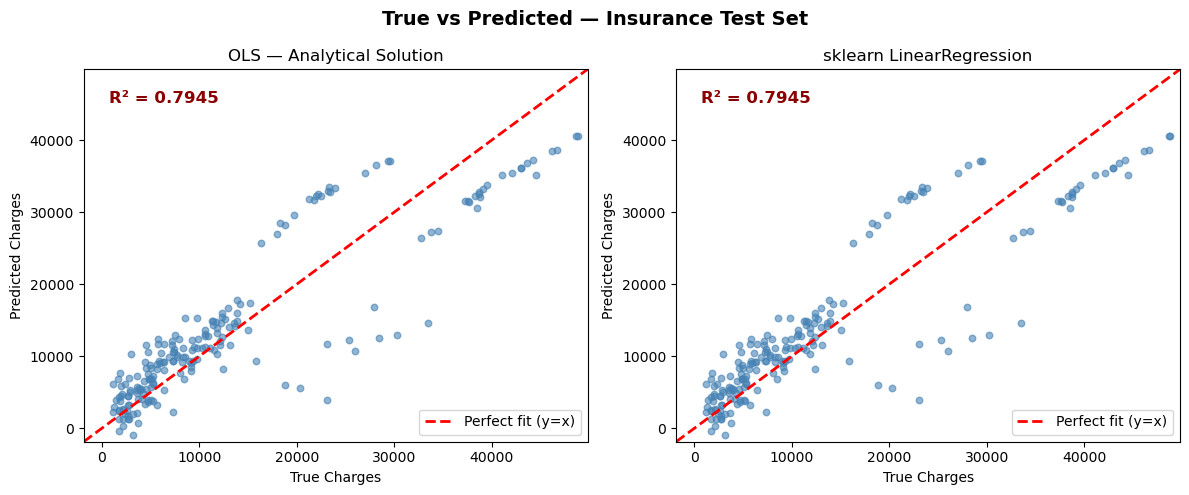

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title, r2_val in zip(
    axes,
    [y_test_ols, y_test_sk],
    ['OLS — Analytical Solution', 'sklearn LinearRegression'],
    [r2_ot, r2_st]
):
    ax.scatter(y_test, y_pred, alpha=0.6, s=22, color='steelblue')
    lims = [min(y_test.min(), y_pred.min())-1000, max(y_test.max(), y_pred.max())+1000]  
    ax.plot(lims, lims, 'r--', lw=2, label='Perfect fit (y=x)')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('True Charges')
    ax.set_ylabel('Predicted Charges')
    ax.set_title(title)
    ax.legend()
    ax.text(0.05, 0.91, f'R² = {r2_val:.4f}', transform=ax.transAxes,
            fontsize=12, color='darkred', fontweight='bold')

plt.suptitle('True vs Predicted — Insurance Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

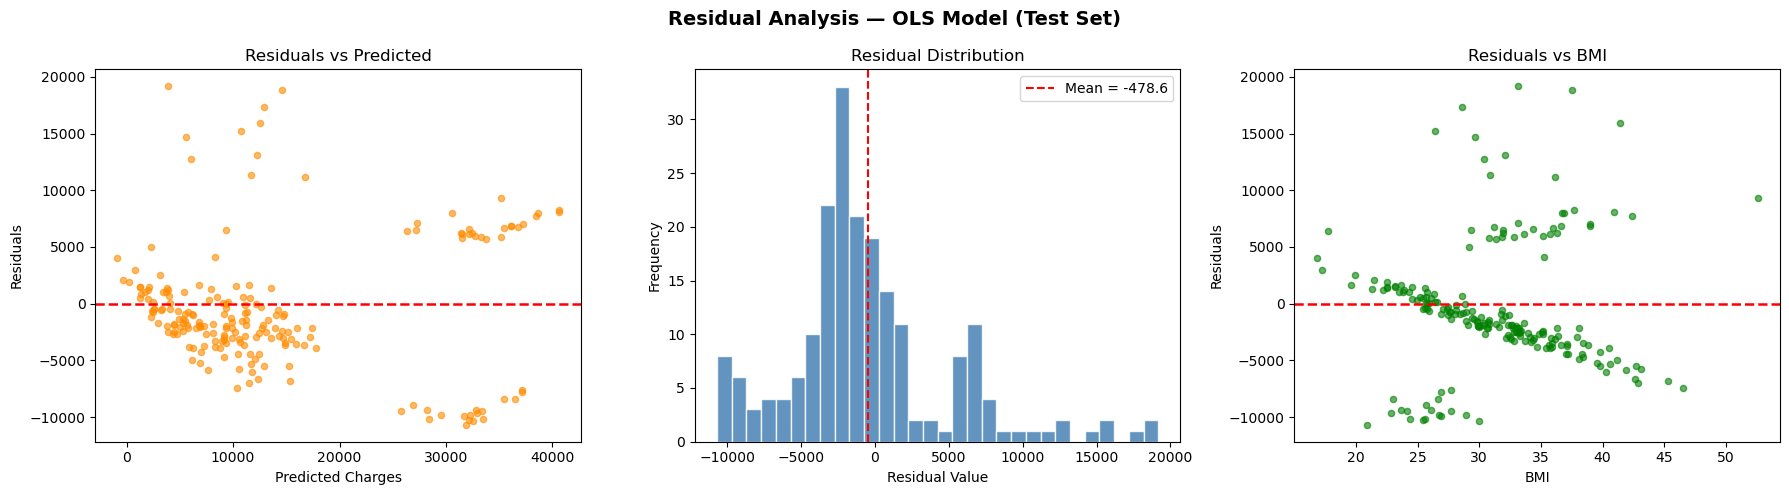

Residual stats — mean: -478.640, std: 5573.962
Min: -10682.0, Max: 19176.5


In [105]:
residuals = y_test - y_test_ols

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


axes[0].scatter(y_test_ols, residuals, alpha=0.6, s=20, color='darkorange')
axes[0].axhline(0, color='red', lw=1.8, ls='--')
axes[0].set_xlabel('Predicted Charges')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted')

axes[1].hist(residuals, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(residuals.mean(), color='red', ls='--', lw=1.5, label=f'Mean = {residuals.mean():.1f}')
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')
axes[1].legend()


if 'bmi' in selected_features:
    bmi_idx = list(selected_features).index('bmi')
    axes[2].scatter(X_test[:, bmi_idx], residuals, alpha=0.6, s=20, color='green')
    axes[2].axhline(0, color='red', lw=1.8, ls='--')
    axes[2].set_xlabel('BMI')
    axes[2].set_ylabel('Residuals')
    axes[2].set_title('Residuals vs BMI')
else:
    axes[2].text(0.5, 0.5, 'BMI not in selected features', ha='center', va='center', fontsize=12)
    axes[2].axis('off')

plt.suptitle('Residual Analysis — OLS Model (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


print(f'Residual stats — mean: {residuals.mean():.3f}, std: {residuals.std():.3f}')
print(f'Min: {residuals.min():.1f}, Max: {residuals.max():.1f}')

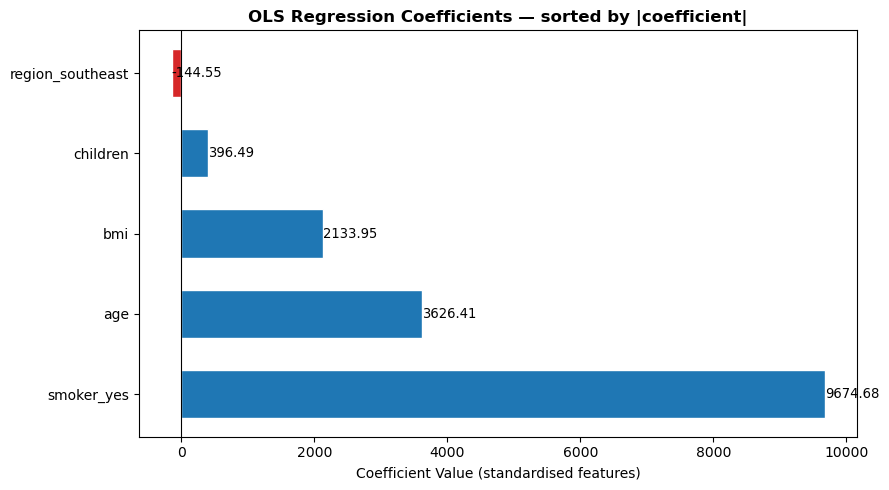

In [108]:
coef_vals = w_ols[1:] 

sorted_idx = np.argsort(np.abs(coef_vals))[::-1]
sorted_feats = [selected_features[i] for i in sorted_idx]  
sorted_coefs = coef_vals[sorted_idx]

colors = ['#d62728' if c < 0 else '#1f77b4' for c in sorted_coefs]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(sorted_feats, sorted_coefs, color=colors, edgecolor='white', height=0.6)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Coefficient Value (standardised features)')
ax.set_title('OLS Regression Coefficients — sorted by |coefficient|', fontweight='bold')

for bar, val in zip(bars, sorted_coefs):
    offset = 0.02 if val >= 0 else -0.02  
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9.5)

plt.tight_layout()
plt.show()

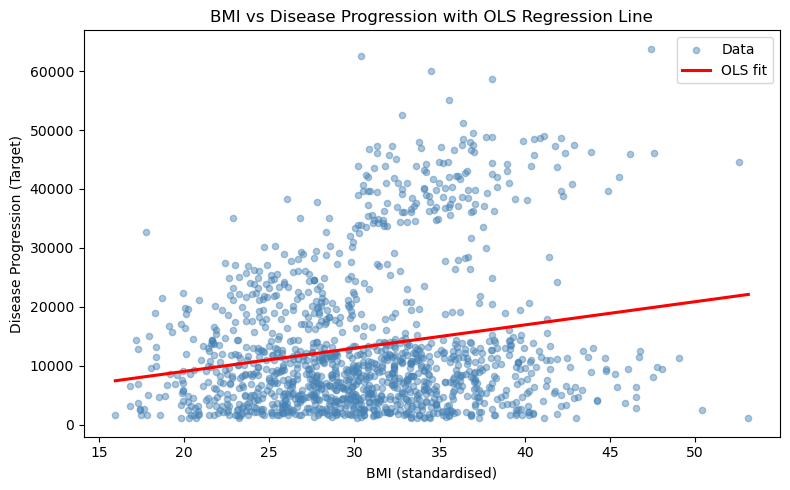

In [109]:
fig, ax = plt.subplots(figsize=(8, 5))


ax.scatter(df['bmi'], df[target_col], alpha=0.45, s=20, color='steelblue', label='Data')


x_line = np.linspace(df['bmi'].min(), df['bmi'].max(), 200)
m, b = np.polyfit(df['bmi'], df[target_col], 1)
ax.plot(x_line, m*x_line + b, 'r-', lw=2.2, label='OLS fit')


ax.set_xlabel('BMI (standardised)')
ax.set_ylabel('Disease Progression (Target)')
ax.set_title('BMI vs Disease Progression with OLS Regression Line')
ax.legend()
plt.tight_layout()
plt.show()

In [111]:
print('COEFFICIENT INTERPRETATION (on standardised features)')
print('='*60)


print(f'Intercept: {w_ols[0]:.2f} → baseline prediction (mean of y_train)')
print()


for name, coef in zip(selected_features, w_ols[1:]):
    direction = 'INCREASES' if coef > 0 else 'DECREASES'
    print(f'{name:>10}: {coef:>8.2f}  → 1 SD increase in {name} {direction} '
          f'disease progression by {abs(coef):.2f} units')


COEFFICIENT INTERPRETATION (on standardised features)
Intercept: 13489.99 → baseline prediction (mean of y_train)

       age:  3626.41  → 1 SD increase in age INCREASES disease progression by 3626.41 units
       bmi:  2133.95  → 1 SD increase in bmi INCREASES disease progression by 2133.95 units
  children:   396.49  → 1 SD increase in children INCREASES disease progression by 396.49 units
smoker_yes:  9674.68  → 1 SD increase in smoker_yes INCREASES disease progression by 9674.68 units
region_southeast:  -144.55  → 1 SD increase in region_southeast DECREASES disease progression by 144.55 units


In [112]:
joblib.dump({
    'model': sk_model,
    'scaler': scaler,
    'ols_weights': w_ols,
    'feature_names': features
}, 'linear_regression_model.joblib')


loaded = joblib.load('linear_regression_model.joblib')
test_pred = loaded['model'].predict(X_test_s[:3])
print('Model saved and verified. Sample predictions:', test_pred.round(2))

Model saved and verified. Sample predictions: [ 8527.91  7231.42 37110.75]
